# Copier le Congrès US : est-ce que ça bat le marché ?

Les membres du Congrès déclarent leurs achats d'actions. **Si on les recopie, gagne-t-on plus que le S&P 500 ?**

On teste **deux stratégies**, comparées au **S&P 500 (SPY)** :
- **A** — copier *tout* le Congrès ;
- **B** — copier seulement les *meilleurs* membres.

Trois chiffres tranchent : **rendement** (CAGR), **risque** (volatilité, pire chute), **rendement ajusté du risque** (Sharpe).

## Partie 0 — Le moteur, brique par brique

On construit d'abord les outils, **une brique par cellule** (rôle + formule). Le notebook est **autonome** : il ne lit que deux entrées de données — la table des transactions et le cache de cours.

### 0.1 Imports & chemins
- `numpy`/`pandas` pour le calcul, `matplotlib` pour les courbes.
- On localise le dossier de données (table des transactions + cache de cours).

In [1]:
import os, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

DATA = None
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = Path(base) / '00. S3S4 en cours'
    if (p/'cache'/'prices').exists(): DATA = p; break
PRICES = DATA/'cache'/'prices'
print("Dossier de données :", DATA)

Dossier de données : /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours


### 0.2 Les achats du Congrès
Une ligne = un membre achète un titre. Colonnes utiles :
- `bioguide` (le membre), `ticker` (l'action), `size_usd` (le montant) ;
- `filed` = date de **déclaration** (ce qu'un copieur voit) ; `traded` = date réelle de l'achat.
- Le Congrès ne déclare que des **fourchettes** → on retient le plancher **1 001 \$** (prudent).

On garde les **achats** d'actions cotées, de 2014 à 2026.

In [2]:
def load_transactions(min_year=2014, max_year=2026):
    d = pd.read_csv(DATA/'table_congres_2014_2026.csv', dtype=str)
    d['filed']  = pd.to_datetime(d['filed'],  errors='coerce')
    d['traded'] = pd.to_datetime(d['traded'], errors='coerce')
    d['size_usd'] = pd.to_numeric(d['size_usd'], errors='coerce').clip(lower=1001.0)
    d = d[d['filed'].notna() & d['traded'].notna()]
    return d[(d['filed'].dt.year >= min_year) & (d['filed'].dt.year <= max_year)].reset_index(drop=True)

df   = load_transactions(2014, 2026)
buys = df[(df['op'] == 'buy') & df['ticker'].notna()].reset_index(drop=True)   # les achats d'actions
print(f"{len(buys):,} achats | {buys['bioguide'].nunique()} membres | années {df['filed'].dt.year.min()}-{df['filed'].dt.year.max()}")

62,018 achats | 263 membres | années 2014-2026


### 0.3 Les cours de bourse & le S&P 500
- `panel` : tableau **dates × actions** de cours de clôture (seulement les titres dont on a l'historique).
- `SPY` : le cours du **S&P 500**, notre unique repère de marché.

In [3]:
def load_prices(tickers):
    cols = {}
    for t in dict.fromkeys(tickers):                     # dédoublonne en gardant l'ordre
        f = PRICES/f'{t}.csv'
        if f.exists(): cols[t] = pd.read_csv(f, index_col=0, parse_dates=True)['close']
    return pd.DataFrame(cols).sort_index()

panel = load_prices(buys['ticker'].dropna().unique())
SPY   = pd.read_csv(PRICES/'SPY.csv', index_col=0, parse_dates=True)['close']
print(f"{panel.shape[1]:,} titres avec cours, sur {panel.shape[0]:,} jours de bourse")

2,117 titres avec cours, sur 3,286 jours de bourse


### 1. La règle de copie → des positions datées
Pour chaque achat copié, on fixe une **entrée** et une **sortie** :

$$\text{entrée} = \text{filed} + 1\text{ jour}, \qquad \text{sortie} = \min\big(\text{vente du membre},\ \text{filed} + 12\text{ mois}\big)$$

- On agit **le lendemain** de la déclaration (jamais avant : aucune triche).
- On revend **quand le membre revend** ; sinon on sort **au bout d'un an**.

In [4]:
def build_sell_map(d):
    """Pour chaque (membre, titre) : la liste triée de ses dates de VENTE."""
    ventes = d[(d['op'] == 'sell') & d['ticker'].notna()]
    return {k: np.sort(g['filed'].values) for k, g in ventes.groupby(['bioguide', 'ticker'])}

def build_positions(bq, sell_map, horizon_months=12):
    """Transforme des achats en positions datées (entrée, sortie, montant)."""
    H = pd.DateOffset(months=horizon_months); rows = []
    for r in bq.itertuples(index=False):
        sortie = r.filed + H                                     # sortie forcée à +12 mois
        ventes = sell_map.get((r.bioguide, r.ticker))
        if ventes is not None:
            apres = ventes[ventes > np.datetime64(r.filed)]      # 1re vente APRÈS l'achat
            if len(apres): sortie = min(sortie, pd.Timestamp(apres[0]))
        rows.append((r.bioguide, r.ticker, r.filed, sortie, float(r.size_usd)))
    return pd.DataFrame(rows, columns=['bioguide', 'ticker', 'entry', 'exit', 'size_usd'])

SELL_MAP = build_sell_map(df)

### 2. Le rendement du portefeuille, jour après jour
Chaque jour, on répartit l'argent sur les positions ouvertes, **proportionnellement au montant** :

$$w_i = \frac{\text{size}_i}{\sum_j \text{size}_j}, \qquad r_t = \sum_i w_{i,\,t-1}\; r_{i,t}$$

- $r_{i,t}$ = variation quotidienne du cours du titre $i$ ; on utilise les poids de **la veille** (on n'agit qu'après coup).
- On retranche des **frais de 20 points de base** (0,20 %) à chaque changement de poids.

In [5]:
def run_portfolio(positions, panel, cost_bps=20.0, lag_days=1):
    idx = panel.index
    ret = panel.pct_change(fill_method=None).clip(-0.5, 0.5).fillna(0.0).values   # rendements quotidiens des titres
    col = {t: i for i, t in enumerate(panel.columns)}
    pos = positions[positions['ticker'].isin(col)].copy()
    if len(pos) == 0: return pd.Series(0.0, index=idx)
    montant = pos['size_usd'].values.astype(float)                                # pondération par la taille
    D, N = ret.shape
    e = idx.searchsorted(pos['entry'].values + np.timedelta64(lag_days, 'D'))      # jour d'entrée (filed+1)
    s = idx.searchsorted(pos['exit'].values)                                       # jour de sortie
    j = pos['ticker'].map(col).values
    detenu = np.zeros((D+1, N)); ok = e < D
    np.add.at(detenu, (e[ok], j[ok]),  montant[ok])                                # +montant à l'entrée
    np.add.at(detenu, (np.clip(s, 0, D)[ok], j[ok]), -montant[ok])                 # -montant à la sortie
    h = np.cumsum(detenu[:D], axis=0); h[h < 0] = 0.0                              # montant détenu par titre et par jour
    tot = h.sum(1, keepdims=True)
    w = np.divide(h, tot, out=np.zeros_like(h), where=tot > 0)                     # poids normalisés (somme = 1)
    w_veille = np.vstack([np.zeros((1, N)), w[:-1]])
    brut  = (w_veille * ret).sum(1)                                                # rendement du portefeuille
    frais = (cost_bps/1e4) * np.abs(w - w_veille).sum(1)                           # frais sur les mouvements
    return pd.Series(brut - frais, index=idx)                                      # rendement NET quotidien

### 3. Les trois mesures de performance
À partir de la série de rendements quotidiens $r_t$ (sur $T$ jours) :

$$\text{CAGR} = \Big(\textstyle\prod_t (1+r_t)\Big)^{252/T} - 1, \qquad \text{vol} = \sigma(r)\sqrt{252}, \qquad \text{Sharpe} = \frac{\bar r}{\sigma(r)}\sqrt{252}$$

- **CAGR** = rendement annualisé ; **vol** = risque annualisé ; **Sharpe** = rendement par unité de risque.
- **maxDD** = pire baisse depuis un sommet (l'ampleur du plus gros krach subi).

In [6]:
def ann_stats(r):
    r = r.dropna(); T = len(r)
    equity = (1 + r).cumprod()
    return {'CAGR':   (1 + r).prod()**(252/T) - 1,
            'vol':    r.std() * np.sqrt(252),
            'sharpe': r.mean() / r.std() * np.sqrt(252),
            'maxDD':  (equity / equity.cummax() - 1).min()}

def bench_daily(price, idx):
    """Rendements quotidiens d'un indice, alignés sur le calendrier du portefeuille."""
    return price.reindex(idx).ffill().pct_change(fill_method=None).fillna(0.0)

### 4. Le rendement réalisé d'un trade
Pour classer les membres (stratégie B), on mesure ce qu'a **vraiment** rapporté chaque achat, de l'entrée à la sortie :

$$\rho = \frac{P_{\text{sortie}}}{P_{\text{entrée}}} - 1$$

On l'attache à chaque achat (colonne `traw`), avec sa date de sortie (`exit_d`).

In [7]:
def trade_returns(positions, panel, lag_days=1):
    out = []
    for r in positions.itertuples(index=False):
        px = panel[r.ticker].dropna() if r.ticker in panel.columns else None
        if px is None or len(px) == 0: out.append(np.nan); continue
        i = px.index.searchsorted(pd.Timestamp(r.entry) + pd.Timedelta(days=lag_days))
        k = min(px.index.searchsorted(pd.Timestamp(r.exit)), len(px) - 1)
        out.append(px.iloc[k]/px.iloc[i] - 1.0 if (i < len(px) and k > i and px.iloc[i] > 0) else np.nan)
    return np.array(out)

def attach_realized(bq, sell_map, panel):
    pos = build_positions(bq, sell_map)
    out = bq.copy()
    out['traw']   = trade_returns(pos, panel)              # rendement réalisé de chaque achat
    out['exit_d'] = pd.to_datetime(pos['exit'].values)     # sa date de sortie
    return out

buys = attach_realized(buys, SELL_MAP, panel)
print(f"rendement réalisé calculé pour {buys['traw'].notna().sum():,} achats")

rendement réalisé calculé pour 51,253 achats


## A. Copier TOUT le Congrès
On réplique **tous** les achats (pondérés par la taille). C'est le point de repère : si « tout copier » battait déjà le marché, inutile de sélectionner quoi que ce soit.

In [8]:
spy_d = bench_daily(SPY, panel.index)
net_A = run_portfolio(build_positions(buys, SELL_MAP), panel)

tab_A = pd.DataFrame({'A - tout le Congres': ann_stats(net_A),
                      'S&P 500 (SPY)':       ann_stats(spy_d)}).T[['CAGR','vol','sharpe','maxDD']]
print(tab_A.to_string(formatters={'CAGR':'{:+.1%}'.format,'vol':'{:.1%}'.format,'sharpe':'{:.2f}'.format,'maxDD':'{:.1%}'.format}))

                      CAGR   vol sharpe  maxDD
A - tout le Congres +13.5% 18.2%   0.79 -31.5%
S&P 500 (SPY)       +14.1% 17.0%   0.86 -33.7%


**Lecture A.**
- « Tout copier » fait **+13,5 %/an** (Sharpe **0,79**) contre **+14,1 %/an** pour le S&P 500 (Sharpe **0,86**).
- Risque quasi identique, mais **un cran en dessous** de l'indice.
- → Copier tout le Congrès, c'est **presque détenir le marché**, sans avantage.

## B. Copier seulement les MEILLEURS
On note chaque membre par le **Sharpe de ses trades passés** :

$$S_{\text{membre}} = \frac{\text{moyenne}(\rho)}{\text{écart-type}(\rho)} \quad\text{sur ses trades clôturés avant fin } N$$

Puis, **sans triche** (walk-forward) : on classe les membres **fin d'année N** et on copie les **10 meilleurs pendant l'année N+1**. On exige au moins **10 trades passés** (sinon le score est du bruit).

In [9]:
def member_sharpe(buys, year, min_trades=10):
    """Sharpe des rendements réalisés de chaque membre, sur ses trades clôturés avant fin `year`."""
    passe = buys[buys['exit_d'] <= pd.Timestamp(year, 12, 31)]
    scores = {}
    for bio, g in passe.groupby('bioguide'):
        r = g['traw'].dropna().values
        if len(r) >= min_trades and r.std() > 0:
            scores[bio] = r.mean() / r.std()
    return scores

def gate_buys(bq, selection):
    """Garde l'achat si son membre était dans la sélection de l'année PRÉCÉDENTE (N -> N+1)."""
    garde = [r.bioguide in selection.get(r.filed.year - 1, []) for r in bq.itertuples(index=False)]
    return bq[pd.Series(garde, index=bq.index)]

                       CAGR   vol sharpe  maxDD
A - tout le Congres  +13.5% 18.2%   0.79 -31.5%
B - les 10 meilleurs +16.2% 21.1%   0.82 -47.0%
S&P 500 (SPY)        +14.1% 17.0%   0.86 -33.7%

Robustesse - Sharpe selon le nombre de membres copiés :


   top  5  ->  Sharpe 0.79   (S&P 500 : 0.86)


   top 10  ->  Sharpe 0.82   (S&P 500 : 0.86)


   top 20  ->  Sharpe 0.79   (S&P 500 : 0.86)


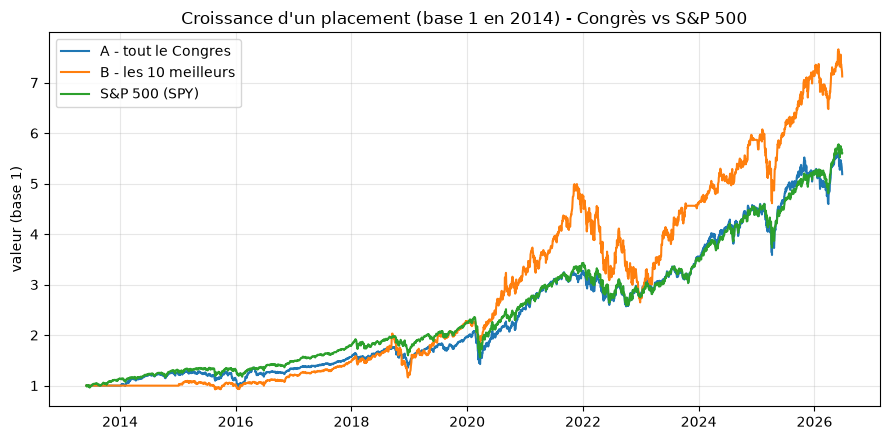

In [10]:
def copier_meilleurs(K):
    selection = {N: [b for b, _ in sorted(member_sharpe(buys, N).items(), key=lambda x: -x[1])[:K]]
                 for N in range(2014, 2026)}
    return run_portfolio(build_positions(gate_buys(buys, selection), SELL_MAP), panel)

net_B = copier_meilleurs(10)
tab = pd.DataFrame({'A - tout le Congres':  ann_stats(net_A),
                    'B - les 10 meilleurs': ann_stats(net_B),
                    'S&P 500 (SPY)':        ann_stats(spy_d)}).T[['CAGR','vol','sharpe','maxDD']]
print(tab.to_string(formatters={'CAGR':'{:+.1%}'.format,'vol':'{:.1%}'.format,'sharpe':'{:.2f}'.format,'maxDD':'{:.1%}'.format}))

print("\nRobustesse - Sharpe selon le nombre de membres copiés :")
for K in [5, 10, 20]:
    print(f"   top {K:2d}  ->  Sharpe {ann_stats(copier_meilleurs(K))['sharpe']:.2f}   (S&P 500 : {ann_stats(spy_d)['sharpe']:.2f})")

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, s in [('A - tout le Congres', net_A), ('B - les 10 meilleurs', net_B), ('S&P 500 (SPY)', spy_d)]:
    ax.plot(s.index, (1 + s).cumprod(), label=label)
ax.set_title("Croissance d'un placement (base 1 en 2014) - Congrès vs S&P 500")
ax.set_ylabel("valeur (base 1)"); ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lecture B.**
- Copier les 10 meilleurs rapporte **plus** — **+16,2 %/an** contre +14,1 % pour le S&P 500 — **mais en prenant beaucoup plus de risque** : volatilité **21 %** (vs 17 %), pire chute **−47 %** (vs −34 %).
- Une fois le risque pris en compte, le **Sharpe (0,82) reste sous celui du S&P 500 (0,86)**.
- Et c'est **robuste** : qu'on copie les 5, 10 ou 20 meilleurs, on reste sous l'indice.

## Verdict

| Stratégie | Rendement/an | Risque (vol) | Pire chute | Ajusté du risque (Sharpe) |
|---|---|---|---|---|
| A — tout le Congrès | +13,5 % | 18 % | −32 % | 0,79 |
| **B — les 10 meilleurs** | **+16,2 %** | **21 %** | **−47 %** | **0,82** |
| **S&P 500 (SPY)** | +14,1 % | 17 % | −34 % | **0,86** |

**Réponse : non, suivre le Congrès ne bat pas le marché à risque égal.**
- **Tout copier** ≈ le marché, un cran en dessous.
- **Copier les meilleurs** gagne un peu **plus**, mais seulement en **prenant plus de risque** — au Sharpe, ça reste **sous le S&P 500**, quel que soit le nombre de membres copiés.
- En clair : le surplus de rendement de la sélection, c'est **du risque en plus, pas du talent**.

**Recommandation.** Un produit « copie du Congrès » se défend comme **pari thématique** (transparence, narratif), **pas** comme promesse de battre le marché.

*Pour aller plus loin (tests statistiques, alpha factoriel, décomposition du risque) → notebook 03.*